In [50]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from itertools import combinations, product

## Phases are drawn from uniform distribution (no synchronization)

In [307]:
fs = 2 # hz
dt = 1/fs
n = 1102

n_vessels = 32

freq = 0.03 # Hz

tvec = np.arange(n)*dt

# x = np.random.randn(n_vessels, tvec.size) + np.cos(2*np.pi*freq*tvec)
times = np.vstack([tvec]*n_vessels)
phases = np.random.uniform(0, 2*np.pi, n_vessels).reshape(n_vessels, 1)
x = np.cos(2*np.pi* ( freq * times + phases ) )

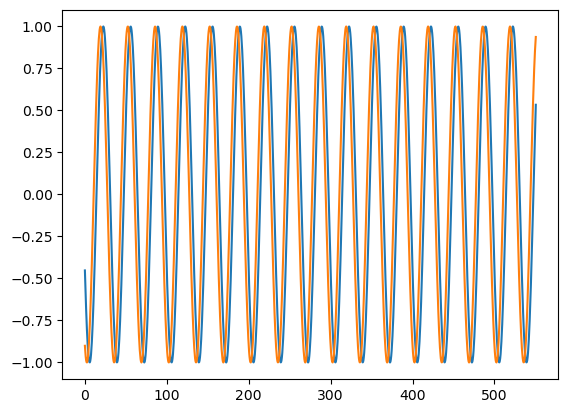

In [308]:
plt.plot(tvec, x[0])
plt.plot(tvec, x[1])

In [309]:
rmtx = np.zeros((n_vessels,n_vessels))

In [310]:
for i, j in combinations(range(n_vessels), 2):
    xi = x[i]
    xj = x[j]

    res = pearsonr(xi, xj)

    rmtx[i,j] = res.statistic

[Text(0.5, 1.0, 'Pearson R'), Text(0, 0.5, 'Vessel'), Text(0.5, 0, 'Vessel')]

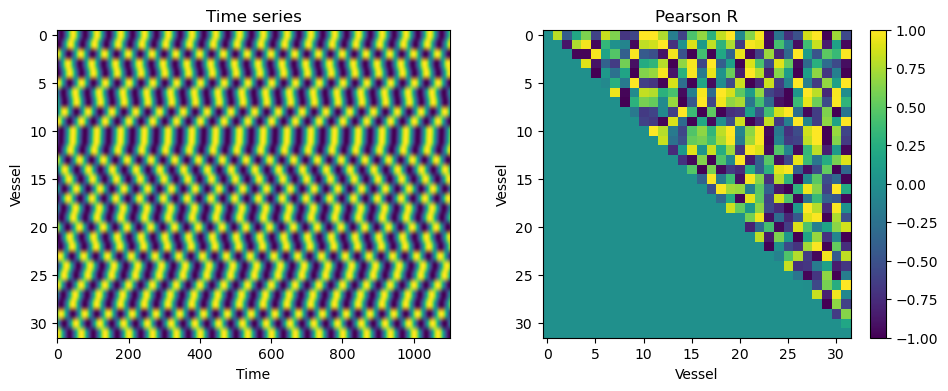

In [311]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(11.3,4))
ax.imshow(x)
ax.set(aspect=27, xlabel='Time', ylabel='Vessel', title='Time series')

im=ax1.imshow(rmtx, vmin=-1, vmax=1)
plt.colorbar(im)
ax1.set(title='Pearson R', ylabel='Vessel', xlabel='Vessel')

In [312]:
rmtx[rmtx!=0].mean().item(), (rmtx[rmtx!=0].std()/np.sqrt(n_vessels)).item()

(0.020903205151880863, 0.12352369965002401)

## Phases are drawn from Gaussian distribution (some synchronization)

In [296]:
fs = 2 # hz
dt = 1/fs
n = 1102

n_vessels = 32

freq = 0.03 # Hz

tvec = np.arange(n)*dt

# x = np.random.randn(n_vessels, tvec.size) + np.cos(2*np.pi*freq*tvec)
times = np.vstack([tvec]*n_vessels)
phases = np.random.normal(loc=0, scale=np.pi/20, size=n_vessels).reshape(n_vessels, 1)
x = np.cos(2*np.pi* ( freq * times + phases ) )

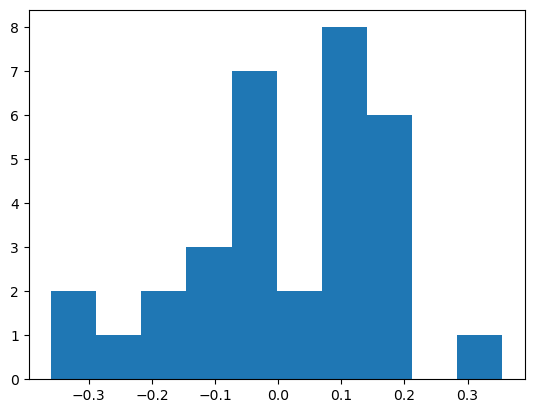

In [297]:
plt.hist(phases);

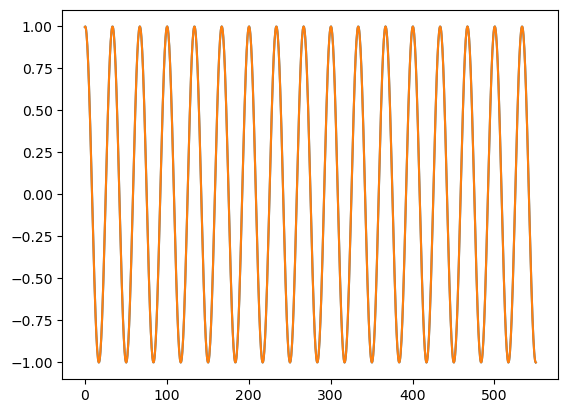

In [298]:
plt.plot(tvec, x[0])
plt.plot(tvec, x[1])

In [299]:
rmtx = np.zeros((n_vessels,n_vessels))

In [300]:
for i, j in combinations(range(n_vessels), 2):
    xi = x[i]
    xj = x[j]

    res = pearsonr(xi, xj)

    rmtx[i,j] = res.statistic

[Text(0.5, 1.0, 'Pearson R'), Text(0, 0.5, 'Vessel'), Text(0.5, 0, 'Vessel')]

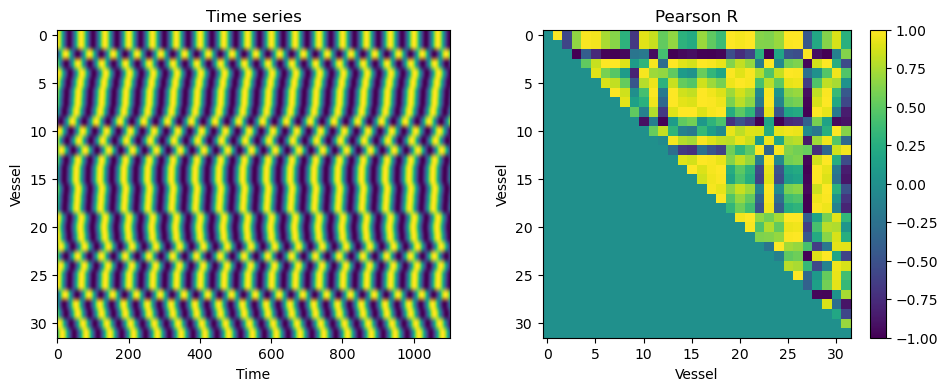

In [301]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(11.3,4))
ax.imshow(x)
ax.set(aspect=27, xlabel='Time', ylabel='Vessel', title='Time series')

im=ax1.imshow(rmtx, vmin=-1, vmax=1)
plt.colorbar(im)
ax1.set(title='Pearson R', ylabel='Vessel', xlabel='Vessel')

In [305]:
rmtx[rmtx!=0].mean().item(), (rmtx[rmtx!=0].std()/np.sqrt(n_vessels)).item()

(0.3537543722127866, 0.11003463084433825)